In [2]:
import pandas as pd

# Load the raw training data (~1.3M rows — give it a few seconds).
# index_col=0 tells pandas the first unnamed column is just a row counter,
# so use it as the index instead of a real feature.
df = pd.read_csv("../data/raw/fraudTrain.csv", index_col=0)

# .shape shows (number of rows, number of columns)
df.shape


(1296675, 22)

In [3]:
df.head(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='str')

In [5]:
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  str    
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  str    
 3   category               1296675 non-null  str    
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  str    
 6   last                   1296675 non-null  str    
 7   gender                 1296675 non-null  str    
 8   street                 1296675 non-null  str    
 9   city                   1296675 non-null  str    
 10  state                  1296675 non-null  str    
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               129667

In [7]:
# Split by fraud flag, then summarize the 'amt' column for each group
df.groupby("is_fraud")["amt"].describe()


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
1,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04


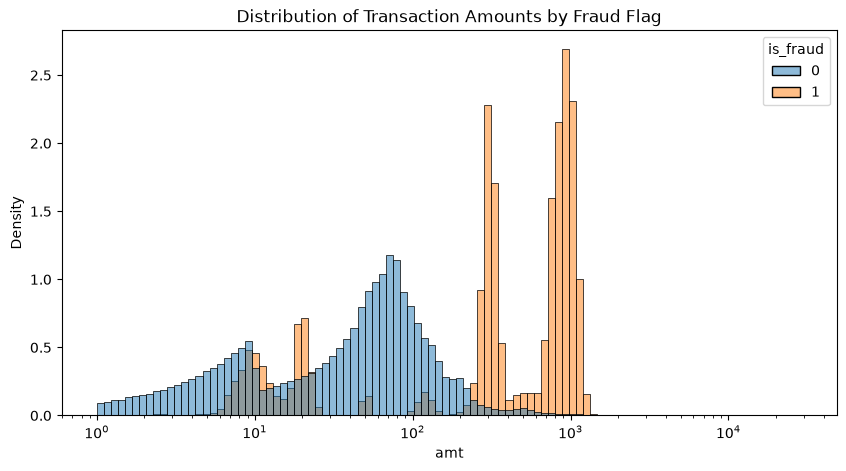

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="amt", hue="is_fraud", bins=100,log_scale=True ,stat="density", common_norm=False ,ax=ax)
ax.set_title("Distribution of Transaction Amounts by Fraud Flag")
plt.show()

**What I did:** Plotted the density of `amt` for fraud vs. legit, using a
log-scaled x-axis (amounts are right-skewed) and per-class normalization
(`common_norm=False`) so the rare fraud class stays visible.

**What I found:**
- Legit transactions cluster around **$50–70**.
- Fraud is **bimodal** — peaks near **$300** and **$700–1,000** — plus a small
  band around **$10–20**, likely *card-testing* before a bigger fraudulent hit.
- Fraud sits mostly to the *right* of legit, where legit transactions are rare.

**Why it matters:** `amt` is a strong predictor, but the signal is **non-linear**
(separated clusters), so tree models (XGBoost) should beat linear ones here.
For Logistic Regression, a **log-transform** of `amt` will help.

In [9]:
# Convert the two text columns into real datetime objects
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

df[["trans_date_trans_time", "dob"]].dtypes

trans_date_trans_time    datetime64[us]
dob                      datetime64[us]
dtype: object

In [10]:
# Extract the hour (0–23) from each timestamp — your first engineered feature!
df["hour"] = df["trans_date_trans_time"].dt.hour

# Fraud rate for each hour of the day
fraud_by_hour = df.groupby("hour")["is_fraud"].mean()
fraud_by_hour


hour
0     0.014940
1     0.015349
2     0.014652
3     0.014239
4     0.001099
5     0.001423
6     0.000946
7     0.001327
8     0.001153
9     0.001114
10    0.000946
11    0.000998
12    0.001027
13    0.001225
14    0.001325
15    0.001208
16    0.001156
17    0.001192
18    0.001226
19    0.001236
20    0.000952
21    0.001129
22    0.028829
23    0.028374
Name: is_fraud, dtype: float64

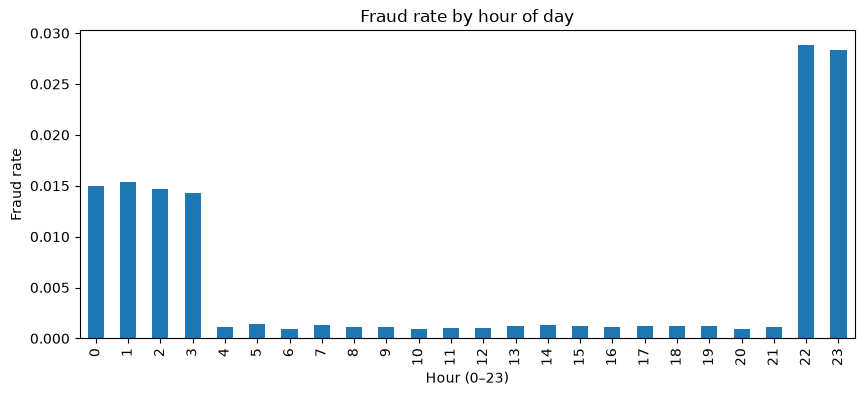

In [11]:
fraud_by_hour.plot(kind="bar", figsize=(10, 4), title="Fraud rate by hour of day")
plt.ylabel("Fraud rate")
plt.xlabel("Hour (0–23)")
plt.show()


**What I did:** Extracted the transaction `hour` (0–23) from the timestamp and
computed the fraud rate per hour using `groupby("hour")["is_fraud"].mean()`
(the mean of a 0/1 column equals the fraction of 1s = the fraud rate).

**What I found:**
- During the day (hours 4–21), the fraud rate sits at only **~0.1%**.
- At night (hours 22, 23, 0, 1, 2, 3), it jumps to **~1.5–2.9%** — a **~20× increase**.
- The pattern is almost a step function: fraud is overwhelmingly a **nighttime** activity,
  when cardholders are asleep and less likely to notice a charge.

**Why it matters:** Hour of day is one of the strongest signals in this dataset.
I will engineer a binary **`is_night`** flag (1 for hours 22–03, else 0) to capture it
in a single clean feature — this should be a top predictor

In [12]:
# 1 if the transaction happened in the high-fraud night window, else 0
df["is_night"] = df["hour"].isin([22, 23, 0, 1, 2, 3]).astype(int)

# Sanity check: fraud rate for night vs. day
df.groupby("is_night")["is_fraud"].mean()

is_night
0    0.001153
1    0.020867
Name: is_fraud, dtype: float64

In [13]:
import numpy as np

def haversine_km(lat1, lon1, lat2, lon2):
    # Convert angles from degrees to radians (trig functions need radians)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    # Haversine formula: gives the great-circle distance on a sphere
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # 6371 km = Earth's radius → result is in kilometers

# Apply it to every row at once (vectorized — fast)
df["distance_km"] = haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"])

df["distance_km"].describe()


count    1.296675e+06
mean     7.611465e+01
std      2.911693e+01
min      2.225452e-02
25%      5.533491e+01
50%      7.823175e+01
75%      9.850327e+01
max      1.521172e+02
Name: distance_km, dtype: float64

In [14]:
# Does fraud happen farther from home? Compare distance for fraud vs. legit.
df.groupby("is_fraud")["distance_km"].describe()


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,76.113756,29.119051,0.022255,55.332701,78.233012,98.504498,152.117173
1,7506.0,76.268330,28.752602,0.738769,55.632890,77.931954,98.391090,144.522410


### 📍 Distance (Cardholder ↔ Merchant) — Tested & Rejected

**What I did:** Computed Haversine distance between cardholder and merchant.

**What I found:** Fraud and legit have nearly identical distance distributions
(mean 76.3 km vs 76.1 km). No separating signal.

**Why:** The Sparkov simulator places merchants randomly within a fixed radius
of the cardholder, independent of fraud — so distance doesn't discriminate here.

**Decision:** ❌ Drop `distance_km`. I validate every engineered feature and keep
only those that earn their place.




In [15]:
# Subtract birthdate from transaction date → a Timedelta (a span of time)
# .dt.days gives that span in days; divide by 365.25 to get years
df["age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25).astype(int)

df["age"].describe()


count    1.296675e+06
mean     4.549541e+01
std      1.739698e+01
min      1.300000e+01
25%      3.200000e+01
50%      4.300000e+01
75%      5.700000e+01
max      9.500000e+01
Name: age, dtype: float64

In [16]:
df.groupby("is_fraud")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,45.479143,17.386860,13.0,32.0,43.0,57.0,95.0
1,7506.0,48.288569,18.849631,14.0,32.0,47.0,60.0,93.0


In [21]:
df.groupby("category")["is_fraud"].mean().sort_values(ascending=False)

category
shopping_net      0.017561
misc_net          0.014458
grocery_pos       0.014098
shopping_pos      0.007225
gas_transport     0.004694
misc_pos          0.003139
grocery_net       0.002948
travel            0.002864
entertainment     0.002478
personal_care     0.002424
kids_pets         0.002114
food_dining       0.001651
home              0.001608
health_fitness    0.001549
Name: is_fraud, dtype: float64

In [22]:
# .dt.dayofweek gives 0 = Monday, 1 = Tuesday, ..., 6 = Sunday
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek

# Fraud rate per day of week
df.groupby("day_of_week")["is_fraud"].mean()

day_of_week
0    0.004648
1    0.005835
2    0.006554
3    0.006844
4    0.007086
5    0.006106
6    0.004853
Name: is_fraud, dtype: float64

In [24]:
df.groupby("gender")["is_fraud"].mean()

gender
F    0.005262
M    0.006426
Name: is_fraud, dtype: float64

# 🔍 EDA Summary — Key Findings

## Dataset
- **1,296,675 transactions**, 22 columns, **no missing values**.
- Simulated (Sparkov) credit-card data with raw features (amount, time, location, category, cardholder info).

## Class imbalance
- Only **0.58% of transactions are fraud** (~1 in 173).
- → Accuracy is meaningless (a trivial "always legit" model scores 99.4%).
- → Primary metric: **PR-AUC**, plus precision & recall on the fraud class.
- → Will compare **class weights** vs **SMOTE** to handle imbalance.

## Feature findings

| Feature | Signal | Evidence | Decision |
|---|---|---|---|
| `amt` | 🥇 Strong | Fraud avg \$531 vs \$67; bimodal at ~\$300 & ~\$900 | Keep — log-transform + scale |
| `hour` / `is_night` | 🥇 Strong | Night (22–03) fraud rate ~2.1% vs ~0.1% day (~18–20×) | Keep — engineered `is_night` |
| `category` | 🥇 Strong | ~12× spread; online (`shopping_net`, `misc_net`) highest | Keep — needs encoding |
| `age` | 🥈 Weak but real | Fraud slightly older (median 47 vs 43) | Keep — secondary |
| `day_of_week` | 🥈 Weak but real | Smooth ~1.5× trend, peaks Thu/Fri | Keep — secondary |
| `gender` | 🥉 Very weak | M 0.64% vs F 0.53% (~1.2×) | Cheap keep — let model vote |
| `distance_km` | ❌ No signal | Fraud vs legit identical (76.3 vs 76.1 km); flat across bins | **Dropped** (verified 2 ways) |

## Modeling implications
1. **Scale** `amt` and `age` (large ranges); **log-transform** `amt` (right-skewed).
2. **Encode** `category` (and `gender`).
3. `amt`'s signal is **non-linear** (separated clusters) → expect **tree models (XGBoost) to beat Logistic Regression**.
4. Drop pure identifiers (`trans_num`, `cc_num`, `street`, `first`, `last`, etc.) to avoid leakage.

## Next steps
- Move keeper logic from notebook → tested `src/` pipeline.
- Preprocess → stratified & time-based split → train XGBoost.
- Evaluate with PR-AUC, precision, recall at chosen thresholds.


In [1]:
import pandas as pd
from fraud_detection.config import TRAIN_CSV
from fraud_detection.data import load_raw_data

df = load_raw_data(TRAIN_CSV)
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
print(df.shape)


(1296675, 22)


In [2]:
# Sort by card, then time — so "previous row" = that card's previous transaction
df = df.sort_values(["cc_num", "trans_date_trans_time"])

# .diff() = this transaction's time minus the PREVIOUS one, per card
df["time_since_last"] = (
    df.groupby("cc_num")["trans_date_trans_time"].diff().dt.total_seconds()
)

# Does fraud have shorter gaps (bursts)? Compare fraud vs legit
df.groupby("is_fraud")["time_since_last"].describe()


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1288261.0,32549.396663,47449.270430,0.0,6064.0,16623.0,40262.0,1341471.0
1,7431.0,21323.662630,36436.695488,1.0,1473.0,4908.0,28974.5,865077.0


### 🏎️ Velocity: Time Since the Card's Previous Transaction

**What I did:** Sorted transactions by card (`cc_num`) then time, and computed
`time_since_last` = seconds since that card's previous transaction using a
per-card `.diff()`. This looks only backward (past transactions), so it's
leakage-safe — exactly what a live model would have.

**What I found:**
- Fraud has a **median gap of ~82 minutes** vs. **~4.6 hours** for legit — about
  **3× shorter**.
- 25% of fraud happens within **~25 minutes** of the card's previous transaction
  (vs. ~1.7 hours for legit).
- This is the classic **burst** pattern: a stolen card gets used rapidly before
  it's blocked.

**Why it matters:** A real, keep-worthy signal (unlike distance, which I rejected).
I'll productionize it as a model feature. Computing it for *live* transactions
requires per-card history — which is exactly the job of the **feature store (Feast,
Phase 5)**.
